### Loading and analyzing Fashion MNIST dataset 

In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pylab as plt

In [5]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### An overview of the images

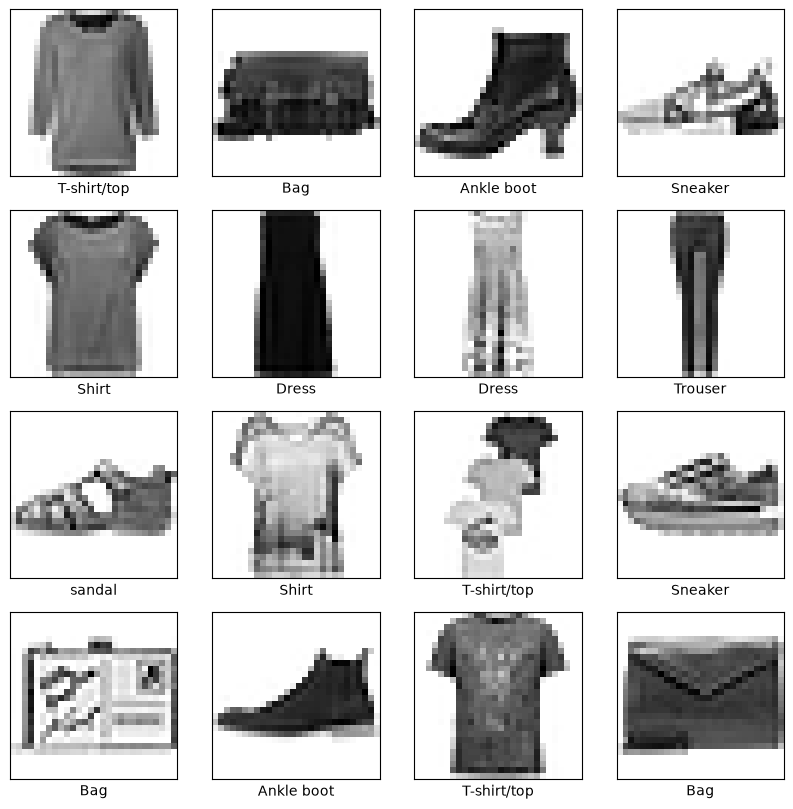

In [7]:
# Get 16 images at random
import random
random.seed(1)
train_idx = list(range(len(train_labels)))
sampler = random.sample(train_idx, 16)

plt.figure(figsize=(10,10))

for i in range(len(sampler)):
    plt.subplot(4, 4, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[sampler[i]], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[sampler[i]]])
plt.show()

### Build, compile and train the model

In [8]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((test_images[:5000], test_labels[:5000]))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images[5000:], test_labels[5000:]))

TRAIN_DATASET_SIZE = len(train_dataset)
VALIDATION_DATASET_SIZE = len(validation_dataset)
TEST_DATASET_SIZE = len(test_dataset)

BATCH_SIZE = 128

train_dataset = train_dataset.shuffle(buffer_size=TRAIN_DATASET_SIZE).batch(BATCH_SIZE)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

#build the model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10),
])

#compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#train the model
model.fit(train_dataset, epochs=10, validation_data=validation_dataset)

_,accuracy = model.evaluate(test_dataset)
print(f"The model accuracy is: {accuracy*100:0.1f}%")

Epoch 1/10


/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/51.TutGator.com-Linkedin-TensorFlow-Working-with-Images/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/51.TutGator.com-Linkedin-TensorFlow-Working-with-Images/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8082 - loss: 0.5476 - val_accuracy: 0.8490 - val_loss: 0.4243
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - accuracy: 0.8612 - loss: 0.3868 - val_accuracy: 0.8458 - val_loss: 0.4207
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - accuracy: 0.8739 - loss: 0.3471 - val_accuracy: 0.8656 - val_loss: 0.3657
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.8820 - loss: 0.3241 - val_accuracy: 0.8736 - val_loss: 0.3517
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.8890 - loss: 0.3020 - val_accuracy: 0.8672 - val_loss: 0.3561
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - accuracy: 0.8934 - loss: 0.2870 - val_accuracy: 0.8720 - val_loss: 0.3611
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - accuracy: 0.8989 - loss: 0.2751 - val_accuracy: 0.8700 - val_loss: 0.3594
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.9024 - loss: 0.2637 - val_accuracy:

### Make Predictions

#### Example 1

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step


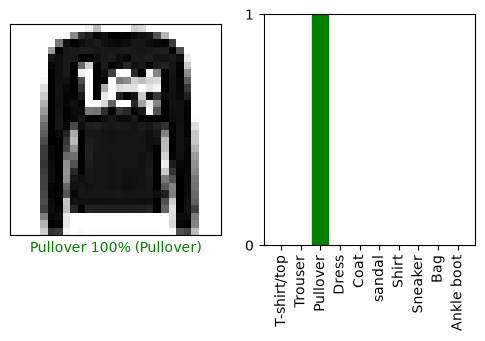

In [9]:
image_id = 1 #pick an image id between 0 and 9999 inclusive

probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(test_images)

def plot_image(i, predictions_array, true_label, img):
    true_label, img =true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                  100*np.max(predictions_array),
                                  class_names[true_label]),
                                  color=color)
def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks(range(10))
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(image_id, predictions[image_id], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(image_id, predictions[image_id], test_labels)
_ = plt.xticks(range(10), class_names, rotation=90)
plt.show()

#### Example 2

Here, actual image is Pullover and model also predicts correctly

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step


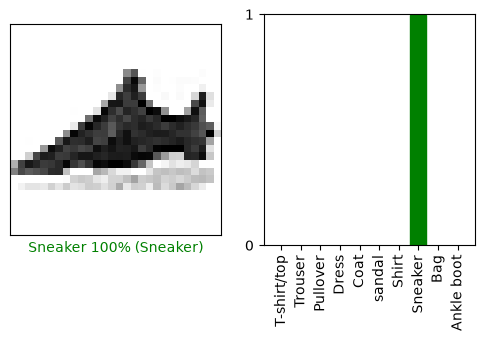

In [10]:
image_id = 1024 #pick an image id between 0 and 9999 inclusive

probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(test_images)

def plot_image(i, predictions_array, true_label, img):
    true_label, img =true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                  100*np.max(predictions_array),
                                  class_names[true_label]),
                                  color=color)
def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks(range(10))
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(image_id, predictions[image_id], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(image_id, predictions[image_id], test_labels)
_ = plt.xticks(range(10), class_names, rotation=90)
plt.show()

Here actual image is sneaker and model also predicts correctly